# **Atividade Prática**
<font size=3>

- **Tema:** problema das 8 rainhas.
- **Prazo de entrega:** 22 de Setembro.
---

## **Enunciado:**
<font size=3>
    
O **problema das 8 rainhas** é um quebra-cabeça clássico e um exemplo canônico em ciência da computação e inteligência artificial. O desafio é simples de enunciar, mas complexo de resolver: posicionar 8 rainhas de xadrez em um tabuleiro 8x8 de tal forma que nenhuma rainha possa atacar qualquer outra. Isso significa que não pode haver duas rainhas na mesma linha, na mesma coluna ou na mesma diagonal.

Para resolver este problema computacionalmente, representamos o tabuleiro inteiro com uma única **lista (ou vetor) de 8 posições**:

* O **índice** da lista (0 a 7) corresponde à **coluna** do tabuleiro.

* O **valor** armazenado nesse índice (0 a 7) corresponde à **linha** onde a rainha daquela coluna está posicionada.


<font size=3>

**Exemplo simplificado:**

Vamos imaginar um mini-tabuleiro 4x4 para facilitar a visualização. Um estado representado pela lista `[1, 3, 0, 2]` seria interpretado assim:

  * `estado[0] = 1` ➔ Na **coluna 0**, a rainha está na **linha 1**.
  * `estado[1] = 3` ➔ Na **coluna 1**, a rainha está na **linha 3**.
  * `estado[2] = 0` ➔ Na **coluna 2**, a rainha está na **linha 0**.
  * `estado[3] = 2` ➔ Na **coluna 3**, a rainha está na **linha 2**.

Visualmente, o tabuleiro ficaria assim:

<font size=2.5>
    
```
    (colunas)
    
   0  1  2  3
  +--+--+--+--+
0 |  |  | Q|  |  (linha 0)
  +--+--+--+--+
1 | Q|  |  |  |  (linha 1)
  +--+--+--+--+
2 |  |  |  | Q|  (linha 2)
  +--+--+--+--+
3 |  | Q|  |  |  (linha 3)
  +--+--+--+--+


```

---

### **1. Questão: busca por escalada**
<font size=3>

- **1.1 Pergunta teórica:** em uma célula **markdown**, descreva por que o algoritmo de **Busca por Escalada** é considerado um exemplo de **busca local**.
  
- **1.2 Implementação:** com base na implementação do algoritmo `HillClimbingSearch` do **_Notebook_ 4**:
  - Termine a implementação da classe `EightQueensProblem` abaixo, com base nas dicas de cada método;
  - Declare uma variável para ser o **estado inicial** do tabuleiro, utilizando o atributo `initial_state` do objeto de `EightQueensProblem`;
  - O **estado final** do tabulerio deve ser encontrado ao realizar a busca do modelo definido;
  - Plot o resultado com a função `plot_result` do pacote `ativ4.py` (**importe o pacote**), ela irá receber os estados **inicial** e **final** do tabuleiro;
  - Verifique se a **solução** foi encontrada.

> **Observação:** faz parte da atividade o(a) estudante investigar as funções e classes contidas em `ativ4.py` e utilizá-las **corretamente**, além de importar qualquer outra biblioteca necessária para cumprir o que se pede na atividade.


### Busca por Escalada (Hill-Climbing Search)

De acordo com Russel & Norvig (2022) em Artificial Intelligence - A Modern Approach, na seção 4.1.1, a Busca por Escalada ou Hill-Climbing Search, às vezes é chamada de busca local ou busca local gulosa, por selecionar um estado vizinho favorável sem realizar um planejamento prévio para os próximos passos.

Entretanto, apesar de apresentar um desempenho considerável ainda pode ficar travada, seja por um máximo local, sequência de *cumes* (Ridges) ou mesmo pelos planaltos (Russel & Norvig, 2022), pois pode não encontrar um vizinho próximo que seja favorável e, com isso, pode acabar se "perdendo" nessas áreas citadas. 

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive/')

In [3]:
import numpy as np
import ativ4

In [11]:
class EightQueensProblem(ativ4.Problem):
    
    def __init__(self, n = 8):
        self.n = n
        initial_state = list(np.random.randint(0, n, size = n))
        
        super().__init__(initial_state = initial_state,
                         actions = self.get_actions,
                         transition_model = self.apply_action)
        
        # A função de valor que queremos maximizar é o número de pares sem ataques:
        self.value_function = self.calculate_non_attacking_pairs

    def calculate_non_attacking_pairs(self, state):
        """Calcula o número de pares de rainhas que não se atacam."""
        
        maxpares = (self.n*(self.n - 1))/2
        conflitos = 0
        for col1 in range(self.n):
            for col2 in range(col1 + 1, self.n):
                if state[col1] == state[col2]:
                    conflitos = conflitos + 1
                elif abs(state[col1] - state[col2]) == abs(col1 - col2):
                    conflitos = conflitos + 1    

        return maxpares - conflitos

    def get_actions(self, state):
        """Gera todas as ações possíveis."""

        actions = []
        for col in range(self.n):
            linha_atual = state[col]
            for nova_linha in range(self.n):
                if nova_linha != linha_atual:
                    actions.append((col, nova_linha))
        return actions    
        
    def apply_action(self, state, action):
        """Aplica uma ação para gerar um novo estado."""

        col, nova_linha = action
        nova_lista = list(state)
        nova_lista[col] = nova_linha
        return nova_lista  

In [12]:
class HillClimbingSearch:

    def __init__(self, problem):
        self.problem = problem

    def search(self):
        """Executa a busca por escalada e retorna o estado de máximo local."""

        current_node = ativ4.Node(self.problem.initial_state)

        while True:
            neighbors = [ativ4.Node(self.problem.transition_model(current_node.state, action))
                          for action in self.problem.actions(current_node.state)]

            if not neighbors:
                break

            best_neighbor = max(neighbors, key = lambda node: self.problem.value_function(node.state))

            neighbor_value = self.problem.value_function(best_neighbor.state)
            current_value = self.problem.value_function(current_node.state)

            if neighbor_value <= current_value:
                return current_node.state

            current_node = best_neighbor

        return current_node.state

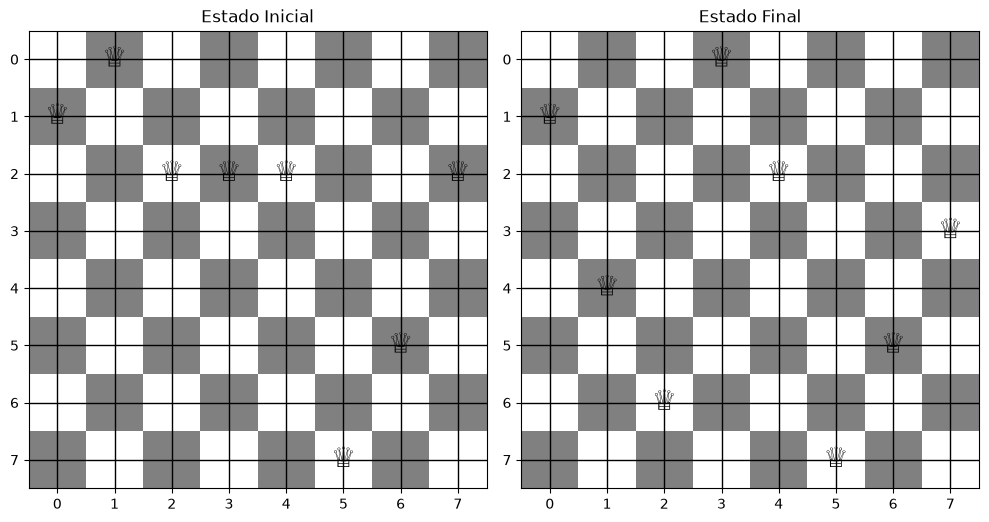

In [16]:
problema = EightQueensProblem()
busca_escalada = HillClimbingSearch(problema)
solucao = busca_escalada.search()

ativ4.plot_result(solucao, problema.initial_state)

### Checagem da solução encontrada
Como o Hill-Climbing Search pode ficar preso em um máximo local, o resultado em que há conflitos pode ser representativo de um máximo local. Para chegar em um máximo global (solução ideal) basta reexecutar algumas vezes até ser alcançado esse estado ideal.

---

### **2. Questão: busca por recozimento simulado**
<font size=3>

- **2.1 Pergunta teórica:** em uma célula **markdown**, descreva por que o algoritmo de **Busca por Recozimento Simulado** pode ser considerado robusto quando comparado à **Busca por Escalada**.
  
- **2.2 Implementação:** com base na implementação do algoritmo `SimulatedAnnealingSearch` do **_Notebook_ 4**:
  - Defina o **estado final** do tabulerio realizando a busca com modelo definido. Reutilize o *objeto* do problema da **questão 1** para declarar o modelo;
  - Plot o resultado com a função `plot_result` de `ativ4.py`, ela irá receber os estados **inicial** (definido na **questão 1**) e **final** do tabuleiro;
  - Verifique se a **solução** foi encontrada.


### Recozimento Simulado (Simulated Annealing)

Segundo o material: [4 - Buscas em ambientes complexos - 1.2](https://colab.research.google.com/drive/1fRm5OgK-FOVPMFeWD8Nx7Uhms037ArRa#scrollTo=c7cb5a9d-5eac-402f-bee9-ab5861708dfd) disponibilizado pelo Prof. Dr. Tibério Pereira, o algoritmo de Busca por Recozimento Simulado pode ser considerado robusto, em comparação à Busca por Escalada, por permitir movimentos para estados piores com uma certa probabilidade. Dessa forma, essa característica acaba evitando que o algoritmo fique preso em máximos locais e aumenta a chance de encontrar o ótimo global.

In [1]:
class SimulatedAnnealingSearch:

    def __init__(self, problem, schedule):
        self.problem = problem
        self.schedule = schedule

    def search(self, max_iterations = 5000):

        current_node = ativ4.Node(self.problem.initial_state)
        best_node = current_node

        for t in range(1, max_iterations):
            T = self.schedule(t) 

            if T < 1e-4: 
                return best_node.state

            actions = self.problem.actions(current_node.state)
            if not actions: break

            random_action = actions[np.random.randint(0, len(actions))]
            next_node = ativ4.Node(self.problem.transition_model(current_node.state, random_action))

            ΔE = self.problem.value_function(next_node.state) - self.problem.value_function(current_node.state)

            if ΔE > 0: 
                current_node = next_node

                if self.problem.value_function(current_node.state) > self.problem.value_function(best_node.state):
                    best_node = current_node

            else: # caso ΔE <= 0:
                probability = np.exp(ΔE/T) 
                                           
                if np.random.rand() < probability:
                    current_node = next_node

        return best_node.state

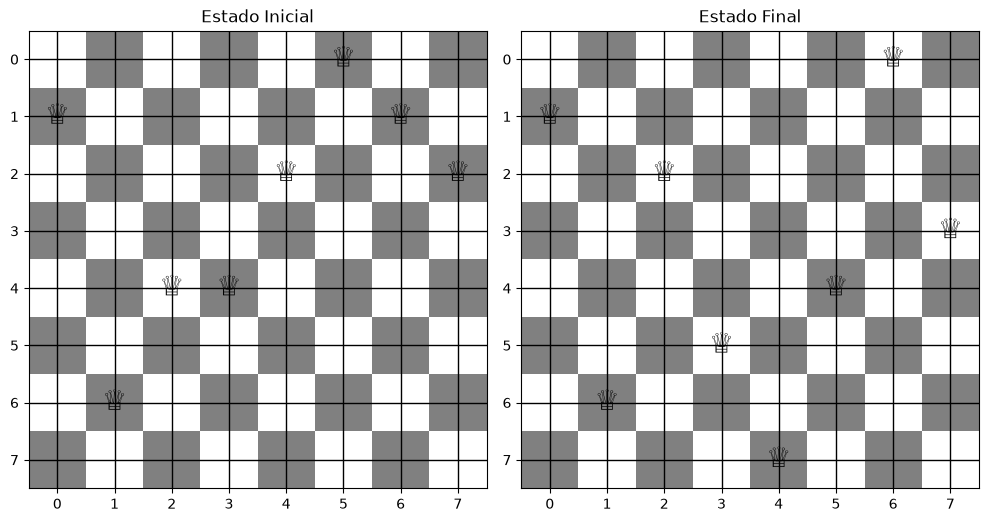

In [20]:
problema1 = EightQueensProblem()

def exponential_schedule(t, temp_initial = 50.0, alpha = 0.995):
    return temp_initial*(alpha**t)

busca_recozimento = SimulatedAnnealingSearch(problema1, exponential_schedule)
solucao1 = busca_recozimento.search()

ativ4.plot_result(solucao1, problema1.initial_state)

### Checagem da solução encontrada

Como esperado, o uso do Recozimento Simulado (Simulated Annealing) acaba trazendo uma solução ótima com mais facilidade do que o Hill-Climbing Search, especialmente por ter essa otimização de permitir ir para estados piores mesmo estando em um máximo local. Porém, como destacado no material [4 - Buscas em ambientes complexos - 1.2](https://colab.research.google.com/drive/1fRm5OgK-FOVPMFeWD8Nx7Uhms037ArRa#scrollTo=c7cb5a9d-5eac-402f-bee9-ab5861708dfd) é necessário estar atento à *função de resfriamento*, que pode comprometer o desempenho do método, pois quanto mais lento o resfriamento, mais tempo o algoritmo poderá levar para chegar na solução, ou seja, é importante se atentar, em particular, ao valor do *alpha* dado na função.

---

### **3. Questão: algoritmo genético**
<font size=3>

- **3.1 Pergunta teórica:** em uma célula **markdown**, descreva as características do **Algoritmo Genético** que se assemelham ao algoritmo de **Busca por Recozimento Simulado**.
  
- **3.2 Implementação:** com base na implementação do algoritmo `GeneticAlgorithmSeach` do **_Notebook_ 4**:
  - Termine a implementação da classe `EightQueensGAProblem` abaixo, com base nas dicas de cada método — problema adaptado para o algoritmo genético;
  - Defina o **estado final** do tabulerio realizando a busca com modelo definido;
  - Plot o resultado com a função `plot_result` de `ativ4.py`. Como o "estado inicial", para este algoritmo, na verdade é uma **população de estados**, vamos considerar o plot apenas do **estado final** do tabuleiro;
  - Verifique se a **solução** foi encontrada.
    

### Algoritmo Genético (Genetic Algorithm Seach) x Busca por Recozimento Simulado (Simulated Annealing)
Apesar de achar esses dois algoritmos profundamente distintos, é possível encontrar algumas pequenas semelhanças entre eles. Nesse sentido, assim como o Recozimento Simulado, os *AGs* também se baseiam em uma probabilidade para decidirem sobre uma ação a ser tomada. Além disso, possuem uma alta chance de retornarem a solução ótima global, principalmente por permitirem sair de estados ótimos locais. Isto posto, também há a questão da estocasticidade, pois ambas as buscas são adequadas para serem utilizadas em 
situações complexas ou incertas, sendo bastante adaptáveis (AGs) ou bastante úteis em problemas com espaços de busca irregulares (Recozimento Simulado) ([Pereira, 2026 - 1.2 e 1.3](https://colab.research.google.com/drive/1fRm5OgK-FOVPMFeWD8Nx7Uhms037ArRa#scrollTo=a188a480-d936-4f13-bd36-b718d099209d)).

Diante do exposto, apesar de poder dizer que são semelhantes nesses aspectos, cabe destacar que a probabilidade não é a mesma em ambas, dado que em uma a probabilidade se baseia na temperatura (Recozimento Simulado) ([Pereira, 2026 - 1.2](https://colab.research.google.com/drive/1fRm5OgK-FOVPMFeWD8Nx7Uhms037ArRa#scrollTo=a188a480-d936-4f13-bd36-b718d099209d)), enquanto que na outra essa probabilidade é dada com base na aptidão (*fitness function*) ([Pereira, 2026 - 1.3](https://colab.research.google.com/drive/1fRm5OgK-FOVPMFeWD8Nx7Uhms037ArRa#scrollTo=a188a480-d936-4f13-bd36-b718d099209d)).

Portanto, mesmo encontrando semelhanças entre elas, é importante estar ciente que não são apectos tão próximos a ponto de poderem ser substituídos entre uma e outra, pois atuam de maneira distintas.

In [18]:
class EightQueensGAProblem:

    def __init__(self, n = 8):
        self.n = n
        self.perfect_score = (n*(n - 1))/2

    def initialize_individual(self):
        """Cria um indivíduo (tabuleiro) aleatório."""

        individuo = np.random.randint(0, self.n, self.n).tolist()

        return individuo

    def fitness(self, individual):
        """Calcula a aptidão do indivíduo (quantidade de pares não-atacantes)."""

        pares_atacantes = 0

        for col1 in range(self.n):
            for col2 in range(col1 + 1, self.n):
                if individual[col1] == individual[col2]:
                    pares_atacantes = pares_atacantes + 1
                elif abs(individual[col1] - individual[col2]) == abs(col1 - col2):
                    pares_atacantes = pares_atacantes + 1    

        return self.perfect_score - pares_atacantes

    def reproduce(self, parent1, parent2, crossover_rate):
        """Realiza o crossover de ponto único entre dois indivíduos pais."""

        aleatorio_num = np.random.rand()

        if aleatorio_num > crossover_rate:
            return parent1[:], parent2[:]
        
        else:
            c = np.random.randint(1, self.n)
            filho1 = parent1[:c] + parent2[c:]
            filho2 = parent2[:c] + parent1[c:]

            return filho1, filho2

    def mutate(self, individual, mutation_rate):
        """Altera a posição da rainha em uma coluna aleatória segundo a taxa de mutação."""

        if np.random.rand() < mutation_rate:
            col = np.random.randint(self.n)
            individual[col] = np.random.randint(self.n)

        return individual
        
    def is_solution(self, fitness):
        """Verifica se o indivíduo atingiu a pontuação máxima (solução perfeita)."""

        return fitness == self.perfect_score


In [19]:
class GeneticAlgorithmSearch:

    def __init__(self, problem, population_size, mutation_rate, crossover_rate):

        self.problem = problem
        self.population_size = population_size
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate


    def _initialize_population(self):
        """Usa o objeto 'problem' para criar a população inicial."""
        return [self.problem.initialize_individual() for _ in range(self.population_size)]


    def _select_parents(self, population, fitnesses):
        """Seleciona dois pais usando o método da roleta."""

        total_fitness = sum(fitnesses)

        if total_fitness == 0:
            parent_indices = np.random.choice(len(population), size = 2, replace=False)

        else:
            selection_probs = [f/total_fitness for f in fitnesses]
            parent_indices = np.random.choice(len(population), size = 2, p = selection_probs, replace = False)

        return population[parent_indices[0]], population[parent_indices[1]]


    def search(self, generations):
        """Executa o Algoritmo Genético."""

        population = self._initialize_population()
        best_individual = None
        best_fitness = -np.inf

        for n in range(generations):
  
            fitnesses = [self.problem.fitness(ind) for ind in population]

            min_fitness = min(fitnesses)
            adjusted_fitnesses = [f - min_fitness + 1e-6 for f in fitnesses]

            current_best_idx = np.argmax(fitnesses)

            if fitnesses[current_best_idx] > best_fitness:
                best_fitness = fitnesses[current_best_idx]
                best_individual = population[current_best_idx]

            if hasattr(self.problem, 'is_solution') and self.problem.is_solution(best_fitness):
                print(f"Solução ótima encontrada na geração {n+1}!")
                break

            new_population = []

            for _ in range(self.population_size//2):
                parent1, parent2 = self._select_parents(population, adjusted_fitnesses)

                child1, child2 = self.problem.reproduce(parent1, parent2, self.crossover_rate)
                new_population.append(self.problem.mutate(child1, self.mutation_rate))
                new_population.append(self.problem.mutate(child2, self.mutation_rate))

            population = new_population

        return best_individual

Solução ótima encontrada na geração 9!


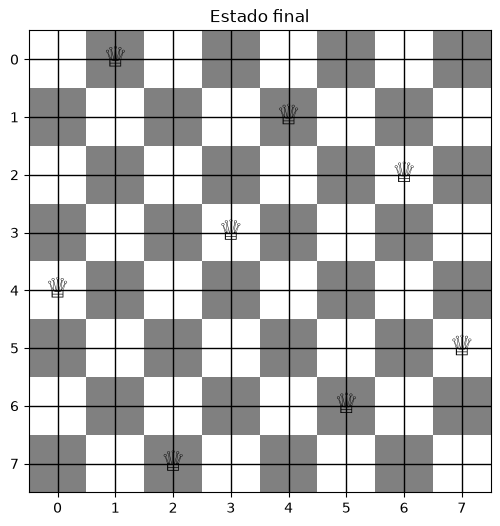

In [31]:
problema2 = EightQueensGAProblem()

busca_ags = GeneticAlgorithmSearch(problema2, population_size = 1000, mutation_rate = 0.02, crossover_rate = 0.8)
solucao2 = busca_ags.search(generations = 100)

ativ4.plot_result(solucao2)

### Checagem da solução encontrada
Inicialmente os parâmetros utilizados não estavam sendo suficientes para gerar uma solução ótima global, pois os valores haviam sido retirados de um exemplo do [material - 1.3](https://colab.research.google.com/drive/1fRm5OgK-FOVPMFeWD8Nx7Uhms037ArRa#scrollTo=31d2e5c9-4e0b-43fe-bb51-568db68f93da), do qual não se trata do mesmo problema. Nesse sentido, ao aumentar o tamanho da população e a taxa de mutação, foi possível gerar, com mais precisão, uma solução ótima global.

### Referências:

- Russell & Norvig. Artificial intelligence: a modern approach, 2022.
- PEREIRA, Tibério. Buscas em ambientes complexos. Disponível em: [material didático](https://colab.research.google.com/drive/1fRm5OgK-FOVPMFeWD8Nx7Uhms037ArRa#scrollTo=11609b15-d16c-4a94-9b6b-041cc35886f0). Acesso em 19/09/2026
